## Carry over the digitization from the raw files to the final output of ICA processing

In [1]:
import numpy as np
import pandas as pd
import time
import os
import pickle
import mne
import sys
import re
from pathlib import Path
import mne
import importlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 
mne.set_log_level(verbose='INFO')
np.set_printoptions(threshold=sys.maxsize)
%matplotlib inline

# dynamic imports to survive MNE version changes
def _import_any(candidates, name):
    last_err = None
    for mod_name, attr in candidates:
        try:
            mod = importlib.import_module(mod_name)
            obj = getattr(mod, attr)
            return obj
        except Exception as e:
            last_err = e
    raise ImportError(f"Could not import {name}; tried: {candidates}") from last_err

fiff_open = _import_any(
    [
        ("mne._fiff.open", "fiff_open"),
        ("mne.io._fiff.open", "fiff_open"),
        ("mne.io.open", "fiff_open"),
        ("mne.io._open", "fiff_open"),
    ],
    "fiff_open",
)

dir_tree_find = _import_any(
    [
        ("mne._fiff.tree", "dir_tree_find"),
        ("mne.io._fiff.tree", "dir_tree_find"),
        ("mne.io.tree", "dir_tree_find"),
    ],
    "dir_tree_find",
)

read_tag = _import_any(
    [
        ("mne._fiff.tag", "read_tag"),
        ("mne.io._fiff.tag", "read_tag"),
        ("mne.io.tag", "read_tag"),
    ],
    "read_tag",
)

from mne.io import read_raw_fif
from mne.io.constants import FIFF

In [2]:
# session info
subject = 'nbl_007'
session = '01'
tasks = ['emcom', 'laryperc', 'sarde'] # 'pharyperc'

meg_dir = '/mnt/sphere/nbl'
pattern = f"{subject}_bigfrank_1_raw.fif"
matches = list(Path(meg_dir, "raw_meg", subject).rglob(pattern))
if not matches:
    raise FileNotFoundError(f"No match for {pattern} under {meg_dir}/raw_meg/{subject}")
if len(matches) > 1:
    raise RuntimeError(f"Multiple matches:\n" + "\n".join(str(m) for m in matches))
raw_fname =  str(matches[0])
print('Raw file:',raw_fname)
proc_fname = os.path.join(meg_dir, 'processed_meg', subject, 'ses-'+session, f"{subject}_ALL_post_ica-raw.fif")
print('Raw file:',proc_fname)

Raw file: /mnt/sphere/nbl/raw_meg/nbl_007/251023/nbl_007_bigfrank_1_raw.fif
Raw file: /mnt/sphere/nbl/processed_meg/nbl_007/ses-01/nbl_007_ALL_post_ica-raw.fif


In [3]:
def densify_polyline(pts: np.ndarray, step_m: float = 0.005) -> np.ndarray:
    pts = np.asarray(pts, float)
    if pts.ndim != 2 or pts.shape[1] != 3 or pts.shape[0] < 2:
        return pts.copy()

    # cumulative arc-length along the polyline
    seg_len = np.linalg.norm(np.diff(pts, axis=0), axis=1)
    t = np.concatenate([[0.0], np.cumsum(seg_len)])
    total_len = float(t[-1])
    if total_len == 0.0:
        return pts.copy()

    n_new = max(2, int(np.ceil(total_len / step_m)) + 1)
    t_new = np.linspace(0.0, total_len, n_new)

    out = np.empty((n_new, 3), dtype=float)
    for d in range(3):
        out[:, d] = np.interp(t_new, t, pts[:, d])
    return out


In [4]:
def extract_megin_string_points(fif_path: str, densify_mm: float | None = 5.0) -> np.ndarray:
    fid, tree, _ = fiff_open(fif_path)
    try:
        nodes = dir_tree_find(tree, FIFF.FIFFB_ISOTRAK)
        clouds = []
        for node in nodes:
            for entry in node["directory"]:
                if entry["kind"] == FIFF.FIFF_DIG_STRING:
                    tag = read_tag(fid, entry["pos"])
                    pts = np.asarray(tag.data, float).reshape(-1, 3)  # meters, HEAD
                    if densify_mm is not None:
                        pts = densify_polyline(pts, step_m=float(densify_mm) / 1000.0)
                    clouds.append(pts)

        if not clouds:
            raise RuntimeError("No FIFF_DIG_STRING (MEGIN strings) found in this file.")

        hsp = np.vstack(clouds)
        return hsp
    finally:
        fid.close()

In [5]:
def _get_directory(node):
    # Works across MNE versions
    return node.get("directory", []) if isinstance(node, dict) else getattr(node, "directory", [])

def _entry_field(entry, name):
    # Works for dict-like and attr-like entries
    return entry.get(name, None) if isinstance(entry, dict) else getattr(entry, name, None)

def parse_dig_string_tag(tag) -> np.ndarray:
    data = tag.data

    # 1) Already array-like?
    try:
        arr = np.asarray(data, float)
        if arr.ndim == 2 and arr.shape[1] == 3:
            return arr
    except Exception:
        pass

    # 2) Dict with direct array under known keys
    if isinstance(data, dict):
        for k in ("r", "rr", "points", "xyz"):
            if k in data:
                arr = np.asarray(data[k], float)
                if arr.ndim == 2 and arr.shape[1] == 3:
                    return arr
        # Dict-of-points: e.g., {'points': [{'r':[x,y,z]}, ...]} or similar
        for k in ("points", "verts", "samples"):
            if k in data and isinstance(data[k], (list, tuple)):
                pts = []
                for itm in data[k]:
                    if isinstance(itm, dict) and "r" in itm:
                        r = np.asarray(itm["r"], float).reshape(-1)
                        if r.size == 3:
                            pts.append(r)
                if pts:
                    return np.vstack(pts)

    # 3) List/tuple of dicts each with 'r'
    if isinstance(data, (list, tuple)) and data and isinstance(data[0], dict):
        pts = []
        for itm in data:
            r = itm.get("r") if isinstance(itm, dict) else None
            if r is not None:
                r = np.asarray(r, float).reshape(-1)
                if r.size == 3:
                    pts.append(r)
        if pts:
            return np.vstack(pts)

    # Last resort: show structure to help adjust parser
    raise TypeError(
        "Unrecognized DIG_STRING tag layout. "
        f"type={type(data)}, repr(head)={repr(data)[:200]}"
    )

def extract_megin_string_points(fif_path, densify_mm: float | None = 5.0) -> np.ndarray:
    """
    Read FIFF_DIG_STRING (MEGIN 'string') polylines and convert to XYZ points (meters, HEAD).
    """
    p = Path(fif_path)  # <-- Keep as Path for this MNE version

    # fiff_open expects Path in your build; keep a fallback to str for portability
    try:
        fid, tree, _ = fiff_open(p)
    except TypeError:
        fid, tree, _ = fiff_open(str(p))

    try:
        nodes = dir_tree_find(tree, FIFF.FIFFB_ISOTRAK)
        clouds = []

        for node in nodes:
            directory = _get_directory(node)
            for entry in directory:
                kind = _entry_field(entry, "kind")
                pos  = _entry_field(entry, "pos")
                if kind == FIFF.FIFF_DIG_STRING and pos is not None:
                    tag = read_tag(fid, pos)
                    pts = parse_dig_string_tag(tag)  # meters, HEAD
                    if densify_mm is not None:
                        pts = densify_polyline(pts, step_m=float(densify_mm) / 1000.0)
                    clouds.append(pts)

        if not clouds:
            raise RuntimeError("No FIFF_DIG_STRING (MEGIN strings) found in this file.")

        hsp = np.vstack(clouds)
        return hsp
    finally:
        fid.close()


In [6]:
# extract the head-shape sample cloud from MEGIN strings
hsp = extract_megin_string_points(raw_fname, densify_mm=None)
print("Head-shape (hsp) points:", hsp.shape, "| mean radius (m):", np.linalg.norm(hsp, axis=1).mean())

Head-shape (hsp) points: (1064, 3) | mean radius (m): 0.11714374346883258


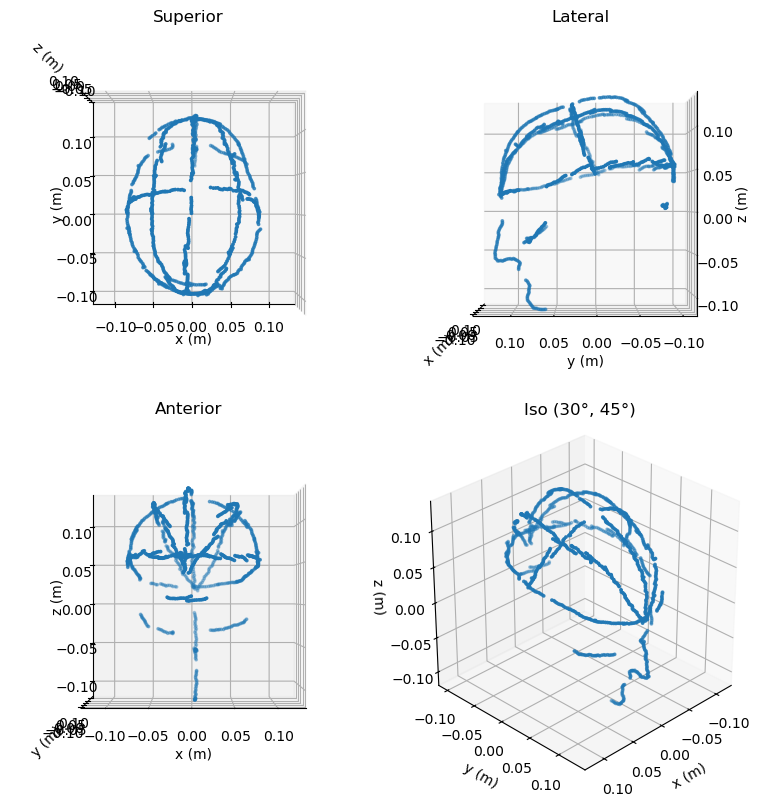

In [7]:
mins = hsp.min(axis=0)
maxs = hsp.max(axis=0)
center = (mins + maxs) / 2.0
radius = np.max(maxs - mins) / 2.0
lims = np.array([center - radius, center + radius])  # shape (2,3)

def set_equal_3d(ax):
    ax.set_xlim(lims[0,0], lims[1,0])
    ax.set_ylim(lims[0,1], lims[1,1])
    ax.set_zlim(lims[0,2], lims[1,2])
    ax.set_box_aspect([1,1,1])

views = [
    ("Superior",   dict(elev=90,  azim=-90)),
    ("Lateral",   dict(elev=0,   azim=180)),
    ("Anterior", dict(elev=0,   azim=-90)),
    ("Iso (30°, 45°)",    dict(elev=30,  azim=45)),
]

fig = plt.figure(figsize=(8,8))
for i, (title, vkw) in enumerate(views, start=1):
    ax = fig.add_subplot(2, 2, i, projection="3d")
    ax.scatter(hsp[:,0], hsp[:,1], hsp[:,2], s=3)
    ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.set_zlabel("z (m)")
    set_equal_3d(ax)
    ax.view_init(**vkw)
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [8]:
from mne.io.constants import FIFF

def _extract_existing_dig(raw):
    """Return dict: {'nasion','lpa','rpa','hpi':(K,3),'hsp':(M,3)} from raw.info['dig']."""
    fids = {'nasion': None, 'lpa': None, 'rpa': None}
    hpi = []
    hsp = []
    for d in (raw.info.get('dig') or []):
        kind = d['kind'] if isinstance(d, dict) else d.kind
        ident = d.get('ident') if isinstance(d, dict) else getattr(d, 'ident', None)
        r = d['r'] if isinstance(d, dict) else d.r
        if kind == FIFF.FIFFV_POINT_CARDINAL and r is not None:
            if ident == FIFF.FIFFV_POINT_NASION: fids['nasion'] = np.asarray(r, float)
            elif ident == FIFF.FIFFV_POINT_LPA:  fids['lpa']    = np.asarray(r, float)
            elif ident == FIFF.FIFFV_POINT_RPA:  fids['rpa']    = np.asarray(r, float)
        elif kind == FIFF.FIFFV_POINT_HPI and r is not None:
            hpi.append(np.asarray(r, float))
        elif kind == FIFF.FIFFV_POINT_EXTRA and r is not None:
            hsp.append(np.asarray(r, float))
    out = dict(**fids)
    out['hpi'] = np.vstack(hpi) if len(hpi) else np.empty((0,3), float)
    out['hsp'] = np.vstack(hsp) if len(hsp) else np.empty((0,3), float)
    return out

def _dedupe_points(A, B, tol=1e-6):
    """Return B without points that are within tol (meters) of any point in A."""
    A = np.asarray(A, float).reshape(-1,3) if A is not None and A.size else np.empty((0,3))
    B = np.asarray(B, float).reshape(-1,3) if B is not None and B.size else np.empty((0,3))
    if A.size == 0: return B
    keep = []
    for r in B:
        if np.all(np.linalg.norm(A - r[None,:], axis=1) > tol):
            keep.append(r)
    return np.vstack(keep) if keep else np.empty((0,3))

def attach_hsp_preserve_dig(raw, hsp_new_m, dedupe_tol=1e-6):
    """
    Append hsp_new_m (N,3) as EXTRA points while preserving existing CARDINAL + HPI.
    Replaces info['dig'] via set_montage().
    """
    # extract digitization in raw
    dig0 = _extract_existing_dig(raw)
    nas, lpa, rpa = dig0['nasion'], dig0['lpa'], dig0['rpa']
    hpi = dig0['hpi']
    hsp_existing = dig0['hsp']

    # merge extra points
    hsp_new = np.asarray(hsp_new_m, float).reshape(-1, 3)
    hsp_add = _dedupe_points(hsp_existing, hsp_new, tol=dedupe_tol)
    hsp_all = np.vstack([hsp_existing, hsp_add]) if hsp_existing.size and hsp_add.size else (hsp_existing if hsp_existing.size else hsp_add)

    # build final montage with cardinals + HPIs + extras
    kwargs = {'coord_frame': 'head'}
    if nas is not None: kwargs['nasion'] = nas
    if lpa is not None: kwargs['lpa'] = lpa
    if rpa is not None: kwargs['rpa'] = rpa
    if hpi.size:        kwargs['hpi'] = hpi
    if hsp_all.size:    kwargs['hsp'] = hsp_all

    mont = mne.channels.make_dig_montage(**kwargs)
    raw.set_montage(mont, on_missing='ignore')

    print(f"Added {0 if hsp_add is None else hsp_add.shape[0]} new EXTRA points")
    return raw

In [9]:
raw_with_hsp = mne.io.read_raw_fif(proc_fname, allow_maxshield=True, preload=True, verbose=False)
raw_with_hsp = attach_hsp_preserve_dig(raw_with_hsp, hsp, dedupe_tol=1e-6)
counts = [sum(((d['kind'] if isinstance(d, dict) else d.kind) == k)
              for d in (raw_with_hsp.info.get('dig') or []))
          for k in (FIFF.FIFFV_POINT_CARDINAL, FIFF.FIFFV_POINT_HPI, FIFF.FIFFV_POINT_EXTRA)]
print(f"Totals: CARDINAL={counts[0]} | HPI={counts[1]} | EXTRA={counts[2]}")

Added 0 new EXTRA points
Totals: CARDINAL=3 | HPI=5 | EXTRA=1064


In [10]:
# save
raw_with_hsp.save(proc_fname, overwrite=True)
print("Saved:", proc_fname)

Overwriting existing file.
Writing /mnt/sphere/nbl/processed_meg/nbl_007/ses-01/nbl_007_ALL_post_ica-raw.fif
Overwriting existing file.
Closing /mnt/sphere/nbl/processed_meg/nbl_007/ses-01/nbl_007_ALL_post_ica-raw.fif
Overwriting existing file.
Writing /mnt/sphere/nbl/processed_meg/nbl_007/ses-01/nbl_007_ALL_post_ica-raw-1.fif
Overwriting existing file.
Closing /mnt/sphere/nbl/processed_meg/nbl_007/ses-01/nbl_007_ALL_post_ica-raw-1.fif
Overwriting existing file.
Writing /mnt/sphere/nbl/processed_meg/nbl_007/ses-01/nbl_007_ALL_post_ica-raw-2.fif
Overwriting existing file.
Closing /mnt/sphere/nbl/processed_meg/nbl_007/ses-01/nbl_007_ALL_post_ica-raw-2.fif
Overwriting existing file.
Writing /mnt/sphere/nbl/processed_meg/nbl_007/ses-01/nbl_007_ALL_post_ica-raw-3.fif
Overwriting existing file.
Closing /mnt/sphere/nbl/processed_meg/nbl_007/ses-01/nbl_007_ALL_post_ica-raw-3.fif
[done]
Saved: /mnt/sphere/nbl/processed_meg/nbl_007/ses-01/nbl_007_ALL_post_ica-raw.fif
